In [1]:
# ==========================================================
# Celda 01 — Importación de paquetes
# ==========================================================
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *
from codes.CSPSA import *


In [2]:
# ==========================================================
# Celda 02 — Definición de funciones base
# ==========================================================

def complex2unitary( Z ):
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

def postprocessing(U):
    return complex2unitary( U )

def trineq(Us, Rho ):

    Us = np.array(Us)
    Us = postprocessing(Us)

    M_per_system = []
    for U in Us:
        M_each_qubit = []
        for u in U:
            M_each_qubit.append( np.outer(u,u.conj()) )
        M_per_system.append( M_each_qubit )
    probs = InnerProductMatrices( Rho, M_per_system ).real
    probs = probs.reshape(6*[2]) 

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1]*probs_clcr[1,0] 
                -probs_clcr[0,0]*probs_clcr[1,1] 
                -probs_clcr[0,1]*probs[1,0,0,1,1,0]
                -probs_clcr[0,1]*probs[1,1,0,0,1,0]
                +probs_clcr[0,0]*probs[1,0,1,1,1,1]
                +probs_clcr[0,0]*probs[1,1,1,0,1,1]
                +probs_clcr[1,0]*probs[0,0,1,0,0,1]
                +probs_clcr[1,0]*probs[0,1,1,1,0,1]
                +probs_clcr[1,1]*probs[0,0,0,0,0,0]
                +probs_clcr[1,1]*probs[0,1,0,1,0,0]
                )
    
    return inequality


In [ ]:
# ==========================================================
# Celda 03 — Construcción de estados locales (Schmidt / Werner) y ensamblado de la red
# ==========================================================

def construir_rho_schmidt_local(a):
    """
    Matriz densidad local (4x4) de una fuente con descomposición de
    Schmidt y parámetro `a`: rho = |psi><psi|, con
    psi = sqrt(a)|01> + sqrt(1-a)|10>.

    Nota de notación: este parámetro se denota \alpha en las gráficas y
    en el texto de la tesis; se mantiene como `a` en el código.
    """
    psi = np.sqrt(a)*np.array([0, 1, 0, 0]) + np.sqrt(1-a)*np.array([0, 0, 1, 0])
    return np.outer(psi, psi.conj())


def construir_rho_werner_local(lam):
    """
    Matriz densidad local (4x4) de una fuente de Werner con parámetro
    de mezcla `lam` (lam=1 -> estado de Bell puro; lam=0 -> estado
    maximamente mixto).

    Nota de notación: este parámetro se denota \lambda en las gráficas y
    en el texto de la tesis; se mantiene como `lam`/`a` en el código.
    """
    psi = np.array([0, 1, -1, 0]) / np.sqrt(2)
    return lam*np.outer(psi, psi.conj()) + (1-lam)*np.eye(4)/4


def construir_rho_werner(a):
    """Alias de construir_rho_werner_local, usado en las celdas de validación
    y en simulaciones puramente de Werner (las tres fuentes con el mismo a)."""
    rho = construir_rho_werner_local(a)
    Rho = triple_kron( rho, rho, rho )
    Rho = Rho.reshape(2*6*[2]).transpose(
            [ 5,0,2,1,4,3, 11,6,8,7,10,9 ]).reshape(2**6, 2**6)
    return Rho


def construir_rho_mixta(rho_alpha, rho_beta, rho_gamma):
    """
    Ensambla la matriz densidad completa de la red triangular a partir
    de las matrices densidad locales (4x4) de cada fuente, sin importar
    si son puras (Schmidt) o mixtas (Werner).
    """
    Rho = triple_kron(rho_alpha, rho_beta, rho_gamma)
    Rho = Rho.reshape(2*6*[2]).transpose(
            [5,0,2,1,4,3, 11,6,8,7,10,9]).reshape(2**6, 2**6)
    return Rho


In [3]:
# ==========================================================
# Celda 04 — Mediciones óptimas y validación del funcional trineq
# ==========================================================
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)

# Validación: dos fuentes Schmidt con alpha=0.5 (máximo entrelazamiento) y
# una fuente Werner con lambda=1.0 (estado de Bell puro) deberían
# converger al mismo valor de referencia (Fritz), ya que en ese límite
# las tres fuentes son equivalentes al estado de Bell antisimétrico.
Rho_validacion = construir_rho_mixta(
    construir_rho_schmidt_local(0.5),
    construir_rho_schmidt_local(0.5),
    construir_rho_werner_local(1.0)
)

trineq( np.array([vec_alice, vec_bob, vec_charlie]), Rho_validacion ), (np.sqrt(2)-1)/16 


NameError: name 'construir_rho_mixta' is not defined

In [4]:
# ==========================================================
# Celda 05 — Simulación mixta: dos fuentes Schmidt (alpha) + una fuente Werner (lambda)
# ==========================================================

def _una_repeticion_sim01(a, lam, gains, max_iter):
    """
    Una repetición de CSPSA para Simulación 01 (mixta): dos fuentes
    Schmidt con parámetro `a` (compartido) y una fuente Werner con
    parámetro `lam`.
    """
    rho_alpha = construir_rho_schmidt_local(a)
    rho_beta = construir_rho_schmidt_local(a)
    rho_gamma = construir_rho_werner_local(lam)

    Rho = construir_rho_mixta(rho_alpha, rho_beta, rho_gamma)

    Us_in = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args=(Rho),
                                postprocessing=postprocessing)
    return results.fun


def ejecutar_simulacion_sim01(alphas, lambdas, max_rep, max_iter, gains, sim_id,
                               carpeta_sim, fecha=None, n_jobs=-1):
    """
    Ejecuta CSPSA para cada combinación (alpha, lambda), paralelizando
    las max_rep repeticiones. Guarda un .npz por cada combinación.
    Nombre de archivo: {sim_id}_alpha{a:.2f}_lambda{lam:.2f}_{fecha}.npz

    Cada archivo contiene:
        Out    -> arreglo crudo (max_rep, max_iter) con todas las realizaciones
        mean   -> promedio por iteración
        median -> mediana por iteración
        q1     -> cuartil 25 por iteración
        q3     -> cuartil 75 por iteración
        a, lam, gains, max_iter, max_rep, sim_id, fecha -> metadatos
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in alphas:
        for lam in lambdas:
            print(f"[{sim_id}] alpha = {a:.2f}, lambda = {lam:.2f}  "
                  f"(paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

            resultados = Parallel(n_jobs=n_jobs)(
                delayed(_una_repeticion_sim01)(a, lam, gains, max_iter) for _ in range(max_rep)
            )
            Out = np.array(resultados)

            nombre = f"{sim_id}_alpha{a:.2f}_lambda{lam:.2f}_{fecha}.npz"
            ruta = os.path.join(carpeta_sim, nombre)

            np.savez(ruta,
                     Out=Out,
                     mean=Out.mean(axis=0),
                     median=np.median(Out, axis=0),
                     q1=np.percentile(Out, 25, axis=0),
                     q3=np.percentile(Out, 75, axis=0),
                     a=a, lam=lam, gains=gains, max_iter=max_iter,
                     max_rep=max_rep, sim_id=sim_id, fecha=fecha)

            print(f"  Guardado: {ruta}")


# Simulación 01

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\alpha$ (dos fuentes Schmidt, mismo valor) | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$ |
| $\lambda$ (una fuente Werner) | $\{0.0,\ 0.2,\ 0.4,\ 0.6,\ 0.8,\ 1.0\}$ |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** barrido 2D combinando dos fuentes con descomposición de
Schmidt (mismo $\alpha$ variable) y una fuente con estado de Werner
($\lambda$ variable), aplicadas a la red triangular. Se generan las
$6\times 6=36$ combinaciones de $(\alpha,\lambda)$; por cada una se guarda
el arreglo crudo de las 100 realizaciones junto con promedio, mediana, Q1
y Q3 por iteración. El resultado se visualiza como un mapa de calor de
$I_{\rm w-w}$ (mediana en $K=1000$) en función de $(\alpha,\lambda)$.

**Archivos generados:** `Simulacion_01/Sim01_alpha{valor_a}_lambda{valor_l}_{fecha}.npz`


In [ ]:
# ==========================================================
# Simulación 01 — Ejecución
# ==========================================================
alphas_sim01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
lambdas_sim01 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
max_rep_sim01 = 100
max_iter_sim01 = 1000
gains_sim01 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim01 = "Simulacion_01"
fecha_sim01 = datetime.now().strftime("%Y%m%d")

ejecutar_simulacion_sim01(alphas_sim01, lambdas_sim01, max_rep_sim01, max_iter_sim01,
                           gains_sim01, "Sim01", carpeta_sim01, fecha_sim01)


# Gráficos

Esta sección se ejecuta **después** de correr la Simulación 01. Se
construye un mapa de calor de $I_{\rm w-w}$ (mediana en $K=1000$) en
función de $(\alpha,\lambda)$.


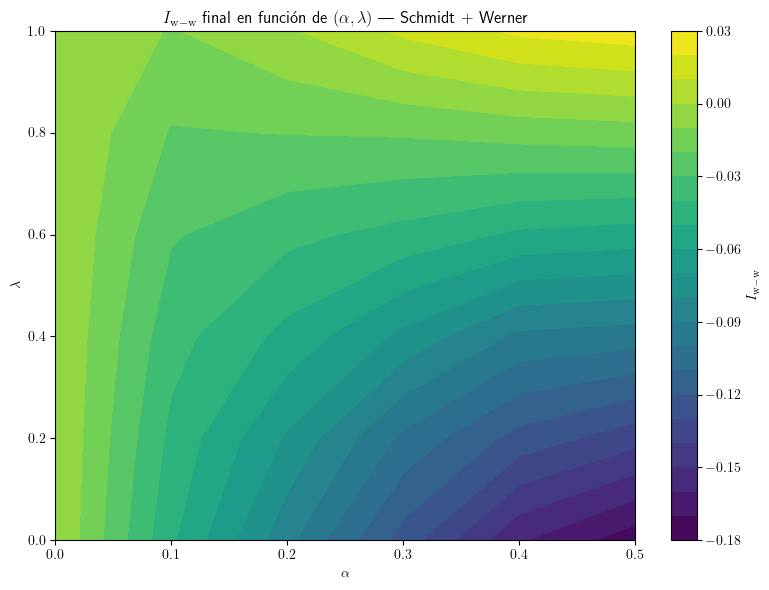

In [6]:
# ==========================================================
# Variables base (por si el kernel se reinició y ya no están definidas)
# ==========================================================
alphas_sim01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
lambdas_sim01 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
carpeta_sim01 = "Simulacion_01"

# ==========================================================
# Heatmap — I_w-w (mediana final) en función de (alpha, lambda)
# ==========================================================
import glob

def cargar_ultimo_npz_mixta(carpeta, sim_id, a, lam):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{a:.2f}_lambda{lam:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró archivo para alpha={a:.2f}, lambda={lam:.2f} en {carpeta}"
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16

matriz_final = np.zeros((len(lambdas_sim01), len(alphas_sim01)))

for i, lam in enumerate(lambdas_sim01):
    for j, a in enumerate(alphas_sim01):
        Data = cargar_ultimo_npz_mixta(carpeta_sim01, "Sim01", a, lam)
        matriz_final[i, j] = Data['median'][-1]

plt.figure(figsize=(8,6))

cont = plt.contourf(alphas_sim01, lambdas_sim01, matriz_final, levels=20, cmap='viridis')
cbar = plt.colorbar(cont)
cbar.set_label(r"$I_{\rm w-w}$")

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\lambda$")
plt.title(r"$I_{\rm w-w}$ final en función de $(\alpha,\lambda)$ — Schmidt + Werner")
plt.tight_layout()
plt.show()


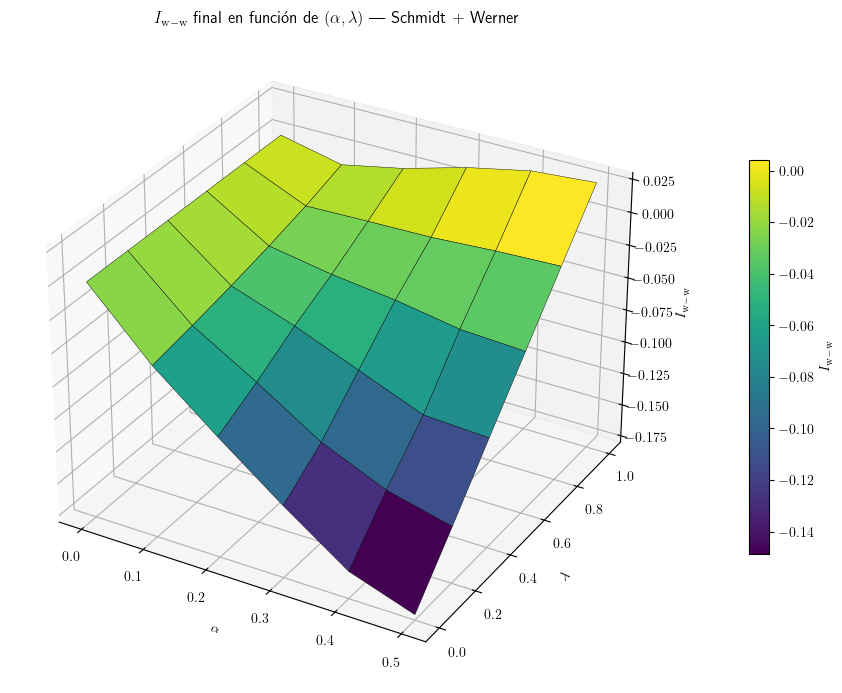

In [7]:
# ==========================================================
# Variables base (por si el kernel se reinició y ya no están definidas)
# ==========================================================
alphas_sim01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
lambdas_sim01 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
carpeta_sim01 = "Simulacion_01"

# ==========================================================
# Superficie 3D — I_w-w (mediana final) en función de (alpha, lambda)
# ==========================================================
import glob
from mpl_toolkits.mplot3d import Axes3D  # necesario para proyección 3D

def cargar_ultimo_npz_mixta(carpeta, sim_id, a, lam):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{a:.2f}_lambda{lam:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró archivo para alpha={a:.2f}, lambda={lam:.2f} en {carpeta}"
    return np.load(archivos[-1])

matriz_final = np.zeros((len(lambdas_sim01), len(alphas_sim01)))

for i, lam in enumerate(lambdas_sim01):
    for j, a in enumerate(alphas_sim01):
        Data = cargar_ultimo_npz_mixta(carpeta_sim01, "Sim01", a, lam)
        matriz_final[i, j] = Data['median'][-1]

X, Y = np.meshgrid(alphas_sim01, lambdas_sim01)  # X=alpha, Y=lambda

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, matriz_final, cmap='viridis', edgecolor='k', linewidth=0.3)

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label(r"$I_{\rm w-w}$")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\lambda$")
ax.set_zlabel(r"$I_{\rm w-w}$")
ax.set_title(r"$I_{\rm w-w}$ final en función de $(\alpha,\lambda)$ — Schmidt + Werner")

plt.tight_layout()
plt.show()